# Decoding PicoQuant TTTR Files (.ptu) and Fit Fluorescence Decays

This script deals with decoding of PicoQuant TTTR files (.ptu) produced by HydraHarp V2. First, the header section is decoded to gain necessary information for proper decoding of the photon record data and the actual microscope image, i.e. the position in x and y where a particular photon record was made. Second, the photon recond data are read and sorted into a 3D array. This array holds the fluorescence decay curves of each pixel and are subsequently fitted to obtain fluorescence lifetimes.

**In this script, only HydraHarp V2 TTTR data are treated and decoded. However, it can easily be expanded to also cover different PicoQuant TCSPC hardware.**

This script is based on PicoQuants' .ptu decoding example (https://github.com/PicoQuant/PicoQuant-Time-Tagged-File-Format-Demos/blob/master/PTU/Python/Read_PTU.py) and an adaption of that script for the PhasorFLIM application written in JavaScript (https://github.com/Tomkaehst/PhasorFLIM/blob/master/app/filedecoding/PTUReaderBitwise.js).


## PTU File Architecture

*.ptu* files consist of a header and record section. In the header, information about the FLIM system and imaging parameters are stored, which are required in order to reconstruct FLIM images from the single photon data encoded in the record section.

### File Magic

*.ptu* files can be identified and verified by the file magic string encoded in the first eight bytes. It should read ```PQTTTR```. The next eight bytes contain the file version (see ).

After file verification, header tags of different data types are read out. The header end is indicated by "Header_End" and can be searched for to know when to stop decoding it. Header data types are indicated by type code tags in each 48 byte header data piece. It is checked to decide what data type should be extracted from the binary file. To read the photon record data from the following file section, the record type has to be known. This is also encoded in the header section.

In [1]:
import sys, struct, io, os
import math
import numpy as np
import time # For measuring code performance
%matplotlib inline 
import matplotlib.pyplot as plt

ptupath = 'testData/EGFP_Cherry_Co_1_1.ptu'
ptureadstream = open(ptupath, 'rb')

filemagic = ptureadstream.read(8).decode('utf8').strip('\0')

# Checking file valiidy by reading file magic and file version
if(filemagic != 'PQTTTR'):
    print('%s is not a .ptu file!' % ptupath)
    ptureadstream.close()
else:
    print('%s is a valid .ptu file... Commencing.' % ptupath)

    
fileversion = ptureadstream.read(8).decode('utf8').strip('\0')
print('File Version: %s' % fileversion)

testData/EGFP_Cherry_Co_1_1.ptu is a valid .ptu file... Commencing.
File Version: 1.0.00


In [2]:
# Definition of header tag types

tyEmpty8      = struct.unpack(">i", bytes.fromhex("FFFF0008"))[0]
tyBool8       = struct.unpack(">i", bytes.fromhex("00000008"))[0]
tyInt8        = struct.unpack(">i", bytes.fromhex("10000008"))[0]
tyBitSet64    = struct.unpack(">i", bytes.fromhex("11000008"))[0]
tyColor8      = struct.unpack(">i", bytes.fromhex("12000008"))[0]
tyFloat8      = struct.unpack(">i", bytes.fromhex("20000008"))[0]
tyTDateTime   = struct.unpack(">i", bytes.fromhex("21000008"))[0]
tyFloat8Array = struct.unpack(">i", bytes.fromhex("2001FFFF"))[0]
tyAnsiString  = struct.unpack(">i", bytes.fromhex("4001FFFF"))[0]
tyWideString  = struct.unpack(">i", bytes.fromhex("4002FFFF"))[0]
tyBinaryBlob  = struct.unpack(">i", bytes.fromhex("FFFFFFFF"))[0]

# Defining record types

rtPicoHarpT3     = struct.unpack(">i", bytes.fromhex('00010303'))[0]
rtPicoHarpT2     = struct.unpack(">i", bytes.fromhex('00010203'))[0]
rtHydraHarpT3    = struct.unpack(">i", bytes.fromhex('00010304'))[0]
rtHydraHarpT2    = struct.unpack(">i", bytes.fromhex('00010204'))[0]
rtHydraHarp2T3   = struct.unpack(">i", bytes.fromhex('01010304'))[0]
rtHydraHarp2T2   = struct.unpack(">i", bytes.fromhex('01010204'))[0]
rtTimeHarp260NT3 = struct.unpack(">i", bytes.fromhex('00010305'))[0]
rtTimeHarp260NT2 = struct.unpack(">i", bytes.fromhex('00010205'))[0]
rtTimeHarp260PT3 = struct.unpack(">i", bytes.fromhex('00010306'))[0]
rtTimeHarp260PT2 = struct.unpack(">i", bytes.fromhex('00010206'))[0]
rtMultiHarpNT3   = struct.unpack(">i", bytes.fromhex('00010307'))[0]
rtMultiHarpNT2   = struct.unpack(">i", bytes.fromhex('00010207'))[0]

## Decoding Header Information
In the first file segment, information about the measurement are encoded in different data types (see PicoQuant TTTR documententation in GitHub repository above).
Each header piece has 48 bytes. 

- 0:32 holds the tag ID (e.g. filename, image dimensions, ...)
- 32:36 holds the tag index
- 36:40 holds tag data type identifier (see above)
- 40:48 holds actual tag value

The header is read in 48 byte chunks until the header end tag is encounterd. The detected tag data type decides how a header piece is treated. If a string is identified, the tag value variable indicates in how many bytes the string in encoded. After treatment, header chunks are stored in the header_contents dictionary.

In [3]:
## setting up header end string to terminate header decoding in while loop 
headerend_tag = 'Header_End'
reached_headerend = False


# tuple that stores decoded information from header section
header_contents = {}

# decoding header
while(reached_headerend == False):
    headerpiece = ptureadstream.read(48)
    tagId = headerpiece[0:32].decode('latin1').strip('\0') # Necessary for non-US computer systems (If I remember correcly..., otherwise utf-8 encoding)
    tagIdx = struct.unpack('<i', headerpiece[32:36])[0]
    tagType = struct.unpack('<i', headerpiece[36:40])[0]
    tagVal = headerpiece[40:48]
    
    if(tagId == headerend_tag):
        reached_headerend = True
        ptureadstream.read(4) # Offset required so that photon records (see second part) are 'in frame'!
        print('Found Header_End.')
        break
    
    if(tagType == tyEmpty8):
        header_contents['Empty'] =  'Empty'
        
    elif(tagType == tyBool8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyInt8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyFloat8):
        value = struct.unpack('<d', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyFloat8Array):
        value = struct.unpack("<q", tagVal)[0]
        print('Float array with %d entries' % value / 8)
        
    elif(tagType == tyAnsiString):
        value = struct.unpack('<q', tagVal)[0]
        string = ptureadstream.read(value).decode('latin1').strip('\0')
        header_contents[tagId] =  string
    
    elif(tagType == tyWideString):
        value = struct.unpack('<q', tagVal)[0]
        string = ptureadstream.read(value).decode('utf-16-le').strip('\0')
        header_contents[tagId] =  string
    
    elif(tagType == tyBinaryBlob):
        value = struct.unpack("<q", tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyBitSet64):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyColor8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  "{0:#0{1}x}".format(value,18)
        
    elif(tagType == tyBinaryBlob):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value

    elif(tagType == tyTDateTime):
        print(' ')
        
    else:
        continue
        #print('Unknown header tag type. Ignored.')
        
    
headerend_bitoffset = ptureadstream.tell() # Needed to quickly jump to photon records instead of header
    
print('Finished header decoding.')

 
Found Header_End.
Finished header decoding.


The releveant header information is now copied into a new structure for convinient access.
In order to reconstruct the FLIM image, several value are required

- Filename: Filename
- Comment: String containing user comments
- TTResultsFormat_TTTRRecType: Type of the photon records i.e. which device was used
- TTResultFormat_BitsPerRecord: Number of bits in a photon record
- ReqHdr_SpatialResolution: Width of a pixel in µm
- ImgHdr_PixX: How many pixels in X?
- ImgHdr_PixY: How many pixels in Y?
- MeasDesc_GlobalResolution: time resolution of measurement
- HW_BaseResolution: Principal time resolution of device
- MeasDesc_Resolution: TCSPC resolution, also obtained by BaseResolution * BinningFactor
- MeasDesc_BinningFactor: Binning factor
- TTResult_SyncRate: Laser pulse / Sync rate of measurement
- TTResult_NumberOfRecords: How many 32 bit records in file?

In [4]:
FLIMInfo = {
    'Filename' : header_contents['$Filename'],
    'RecordType' : header_contents['TTResultFormat_TTTRRecType'],
    'BitsPerRecord' : header_contents['TTResultFormat_BitsPerRecord'],
    'PixelResolution' : header_contents['$ReqHdr_SpatialResolution'],
    'PixelsX' : header_contents['ImgHdr_PixX'],
    'PixelsY' : header_contents['ImgHdr_PixY'],
    'GlobalResolution' : header_contents['MeasDesc_GlobalResolution'],
    'BaseResolution' : header_contents['HW_BaseResolution'],
    'Resolution' : header_contents['MeasDesc_Resolution'],
    'BinningFactor' : header_contents['MeasDesc_BinningFactor'],
    'SyncRate' : header_contents['TTResult_SyncRate'],
    'NumberOfRecords' : header_contents['TTResult_NumberOfRecords']
}
FLIMInfo

{'Filename': 'EGFP_Cherry_Co_1_1',
 'RecordType': 16843524,
 'BitsPerRecord': 32,
 'PixelResolution': 2.1623884549626382e-07,
 'PixelsX': 1024,
 'PixelsY': 1024,
 'GlobalResolution': 5.141430469350905e-08,
 'BaseResolution': 9.999999960041972e-13,
 'Resolution': 1.5999999936067155e-11,
 'BinningFactor': 16,
 'SyncRate': 19449840,
 'NumberOfRecords': 3153288}

## Decoding Photon Records
After header reading, we have sufficient information to decode the photon data from the ```.ptu``` file. **Because in this script, only HydraHarp V2 TTTR data are decoded**, only this record type is considered.

### Photon Data Architecture
A HydraHarp V2 TTTR record has 32 bits and encodes three types of information:
- marker
    - Indicates channel in which photon was detected, of regular photon record occured
    - Indicates several special records
        - macro time overflow
        - frame and line start or stop
- macro time
- nano time


#### Meaning of Marker Events



In [5]:
ptureadstream.close()

### Rewriting *.ptu* Decoding with NumPy 
Only photon record section for now. Byte offset until photon records saved above after ```Header_End``` tag has been detected.

In [6]:
# Function treating overflows and recover macrotimes

from numba import jit # Attempting numba acceleration of this task

@jit(nopython = True)
def treatOverflows(recordarray, macrotimefactor):
    overflow_period = 1024
    overflow_cor = 10
    
    for record in recordarray:
        if(record['marker'] == 127):
            overflow_cor = overflow_cor + overflow_period * (record['record'] & (2^10 -1))
            
        record['macrotime'] = overflow_cor + ((record['record'] & 1023) * macrotimefactor)
    
    return(recordarray)
    



In [7]:
## Trying to use NumPy for binary decoding and processing

# measure time performance
start = time.clock()

# Initializing numpy array holding photon data
## record: raw TCSPC data from binary file, UInt32, see PicoQuant
## marker:
## nanotime:
## macrotime:

recordBitType = np.dtype([('record', np.uint32), ('marker', np.uint8), ('nanotime', np.float64), ('macrotime', np.float64)])


# Preallocating array with decoded raw FLIM data
flimarray = np.zeros(shape = FLIMInfo['NumberOfRecords'] - 1,dtype = recordBitType)

# Factors required to recover real macro and nanotimes from raw photon data stream
macroMultFactor = FLIMInfo['GlobalResolution'] # Multiply with truensync to get experiment macro time
nanoMultFactor = FLIMInfo['Resolution'] * 1e9


# Opening .ptu file and shoveling it into UInt32 section of preallocated array
with open(ptupath, 'rb') as file:
    file.seek(headerend_bitoffset)
    flimarray[:]['record'] = np.fromfile(file, dtype = np.uint32)
    file.close()
    
# Recover marker signals and nanotimes of photon events
flimarray[:]['marker'] = np.right_shift(flimarray[:]['record'], 25)
flimarray[:]['nanotime'] = np.right_shift(flimarray[:]['record'], 10)* nanoMultFactor

# Recover macrotimes and treat overflows
treatOverflows(flimarray, macroMultFactor)

# Stop timer to measure time performance
stop = time.clock()

print(stop - start)


0.240996


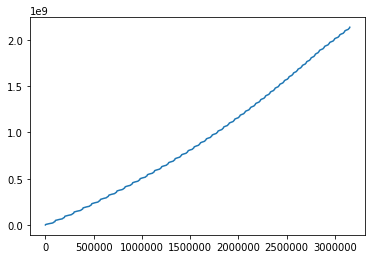

In [8]:
plt.plot(flimarray['macrotime'])
plt.show()

## Reconstructing Image from Data Stream

In [9]:
# Counting number of lines

def countLines(flimarray):
    numLinesStart = np.sum(flimarray['marker'] == 65)
    numLinesStop = np.sum(flimarray['marker'] == 66)
    
    if(numLinesStart != numLinesStop):
        print("Line start and stop numbers not equal. Corrupted file?")
    
    return numLinesStart

In [10]:
FLIMInfo['LinesInFile'] = countLines(flimarray)

In [11]:
# Extracting line start and line stop positions -> Goal: slice values inbetween

lineStart = np.where(flimarray['marker'] == 65)[0]
lineStop = np.where(flimarray['marker'] == 66)[0]





# Initialize arry for intensity image
intensityImage = np.zeros((FLIMInfo['PixelsX'], FLIMInfo['PixelsY']), dtype = np.int16)

In [12]:
FLIMInfo

{'Filename': 'EGFP_Cherry_Co_1_1',
 'RecordType': 16843524,
 'BitsPerRecord': 32,
 'PixelResolution': 2.1623884549626382e-07,
 'PixelsX': 1024,
 'PixelsY': 1024,
 'GlobalResolution': 5.141430469350905e-08,
 'BaseResolution': 9.999999960041972e-13,
 'Resolution': 1.5999999936067155e-11,
 'BinningFactor': 16,
 'SyncRate': 19449840,
 'NumberOfRecords': 3153288,
 'FramesInFile': 51200}

In [55]:
@jit(nopython=True)
def assignNanotimes(flimarray, channel, framesinfile, pixelsx, pixelsy):
    # assign nanotimes to 3D FLIM Image array
    #flimimage = np.zeros((FLIMInfo['PixelsX'],
    #                     FLIMInfo['PixelsY'],
    #                      round(FLIMInfo['GlobalResolution'] / FLIMInfo['BaseResolution'])),
    #                    dtype = (np.int8))
    

    eventCounter = int(0)
    lineCounter = 0
    frameCounter = 0
    framesInFile = framesinfile / pixelsx
    
    pixelTime = 0
    
    lineStart = 0
    lineStop = 0
    
    lastLine = False
    lineActive = False
    
    
    tmpEvents = [np.float64(x) for x in range(0)]
    tmpNano = [np.float64(x) for x in range(0)]
    tmpMarker = 0
    tmpMacro = 0
    tmpNanotime = 0
    diff = 0
    
    pixelIDX = 0
    pixelIDY = 0
    
    intensityImage = np.zeros((pixelsx, pixelsy), dtype = np.int16)
    
    
    while(lastLine == False):
        tmpMarker = flimarray['marker'][eventCounter]

        if(tmpMarker == 65):
            lineActive = True
            lineStart = flimarray['macrotime'][eventCounter]
            eventCounter = eventCounter + 1
            #continue
            
            
        while(lineActive == True):
            tmpMarker = flimarray['marker'][eventCounter]
            tmpMacro = flimarray['macrotime'][eventCounter]
            tmpNanotime = flimarray['nanotime'][eventCounter]
            
            
            if(tmpMarker == channel):
                tmpEvents.append(tmpMacro)
                tmpNano.append(tmpNanotime)
            elif(tmpMarker == 66):
                lineActive = False
                lineStop = tmpMacro
                pixelTime = (lineStop - lineStart) / pixelsy
                for photon in tmpEvents:
                    diff = photon - lineStart
                    pixelIDY = math.floor(diff / pixelTime)
                    
                    if(pixelIDY < 0 or pixelIDY > (pixelIDY - 1)):
                        #print("Photon out of image range!")
                        if(pixelIDY < 0):
                            pixelIDY = 0
                        elif(pixelIDY > (pixelsy - 1)):
                            pixelIDY = pixelsy - 1
                            
                    intensityImage[pixelIDX][pixelIDY] = intensityImage[pixelIDX][pixelIDY] + 1
                    
                pixelIDX = pixelIDX + 1
                lineCounter = lineCounter + 1
                tmpEvents = [np.float64(x) for x in range(0)]
                tmpNano = [np.float64(x) for x in range(0)]
                
            eventCounter = eventCounter + 1
            
            
            
            
        eventCounter = eventCounter + 1
            
        if(lineCounter >= (pixelsx - 1)):
            #print("Finished scanning frame %d", frameCounter)
            frameCounter = frameCounter + 1
            pixelIDX = 0
            lineCounter = 0
            
        if(frameCounter >= framesInFile):
            lastLine = True
            break
        
    return intensityImage

In [56]:
intImage = assignNanotimes(flimarray, 0, FLIMInfo['FramesInFile'], FLIMInfo['PixelsX'], FLIMInfo['PixelsY'])

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
1
1
1
1
1
1
1
2
2
2
2
2
3
3
3
4
5
5
5
5
5
6
6
6
7
8
8
8
8
8
8
8
8
8
8
8
8
8
9
9
9
10
10
10
10
10
11
11
11
11
11
11
11
11
11
11
11
12
12
12
12
12
12
12
12
13
13
13
13
13
13
13
14
14
14
14
14
14
14
15
15
15
15
15
15
15
15
15
16
17
17
17
18
18
18
18
18
19
19
19
19
19
20
20
20
20
20
20
20
20
20
21
21
21
21
21
21
21
21
21
21
22
22
22
22
22
22
22
22
22
23
23
23
24
24
24
24
24
24
24
24
25
25
25
25
25
25
26
26
26
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
28
28
28
28
28
28
28
29
29
29
29
29
29
29
29
29
29
2

476
476
476
476
476
476
477
477
477
477
477
478
478
478
478
478
479
479
479
479
479
480
480
480
480
480
480
480
480
480
480
481
481
481
481
481
481
481
482
482
482
483
483
483
483
483
483
483
483
483
484
484
484
485
485
485
486
486
486
486
486
487
487
487
487
487
487
487
487
487
487
487
487
488
488
488
488
488
488
488
489
489
489
490
490
490
490
490
491
491
491
491
491
491
491
491
492
492
492
493
493
493
493
493
493
493
494
494
494
495
495
495
495
495
496
496
496
496
496
496
496
496
496
496
496
496
496
497
497
497
498
498
498
498
498
498
498
499
499
499
499
500
500
500
500
500
501
501
501
501
501
502
502
502
502
502
502
502
503
503
503
504
504
504
504
504
505
506
506
506
506
506
506
506
507
507
507
507
507
507
507
507
507
507
508
508
508
508
508
509
509
509
509
509
509
509
510
510
510
510
510
510
510
510
510
510
511
511
511
512
512
512
513
513
513
514
514
514
514
514
514
515
515
515
515
515
515
515
515
515
516
516
516
516
516
517
517
517
517
517
518
518
518
518
518
519
519
519
520
521


13
13
13
13
13
13
13
13
14
15
15
15
16
16
16
16
16
17
17
17
17
17
17
17
18
18
18
18
18
18
18
19
19
19
19
19
19
19
20
20
20
20
20
20
20
21
21
21
21
21
22
22
22
22
22
22
22
22
22
22
22
22
22
22
22
23
23
23
23
23
23
23
23
23
24
24
24
25
25
25
25
25
26
26
26
26
26
26
26
26
26
27
27
27
27
27
28
28
28
28
28
28
28
29
29
29
29
29
30
31
31
31
31
31
31
31
32
32
32
32
33
33
33
33
33
34
34
34
35
35
35
35
35
35
35
35
35
36
36
36
36
36
37
37
37
37
37
38
38
38
38
38
38
38
39
39
39
39
39
40
40
40
40
40
40
40
40
40
40
41
41
41
42
42
42
42
42
43
43
43
43
43
44
44
44
44
44
44
44
45
45
45
46
46
46
46
46
47
48
48
48
49
50
50
50
51
51
51
51
51
51
51
52
52
52
53
54
54
54
54
54
54
54
55
55
55
56
56
56
56
56
56
56
56
56
56
56
56
57
57
57
58
58
58
58
58
58
58
59
59
59
59
59
59
59
59
59
60
60
60
60
60
61
61
61
61
61
61
61
62
62
62
63
63
63
63
63
64
65
65
65
65
65
65
65
66
66
66
66
66
66
66
67
67
67
67
67
67
67
68
68
68
68
68
69
69
69
69
69
69
69
70
70
70
70
70
71
71
71
71
71
71
71
72
72
72
72
72
73
73
73
73
73
7

623
623
623
623
623
624
625
625
625
625
625
625
625
625
625
625
625
625
625
626
627
627
627
627
627
627
628
628
628
628
628
628
628
629
629
629
629
629
629
629
630
630
630
631
631
631
631
631
631
631
632
632
632
633
633
633
633
633
633
633
633
633
633
633
633
633
633
633
634
634
634
634
634
635
635
635
635
635
635
635
635
635
635
635
636
636
636
636
636
636
636
637
637
637
637
637
638
638
638
638
638
638
638
639
639
639
639
639
639
639
640
640
640
640
640
640
640
641
641
641
642
642
642
642
642
643
643
643
643
643
644
644
644
644
644
645
645
645
645
645
645
645
646
646
646
646
646
646
646
647
647
647
647
647
647
648
648
649
649
649
649
649
649
649
649
649
650
650
650
650
650
650
651
651
651
651
651
651
651
651
651
651
651
652
652
652
653
653
653
653
653
653
653
653
653
654
654
654
654
654
654
654
654
654
654
654
655
655
655
655
655
655
655
655
655
655
655
656
656
656
656
656
657
657
657
657
657
658
658
658
659
659
659
659
659
659
659
660
660
660
661
661
661
661
661
662
662
662
662
662


233
233
233
233
233
233
233
233
233
233
233
233
234
234
234
234
234
235
235
235
235
235
235
235
236
236
236
236
236
236
236
237
237
237
237
237
237
237
238
238
238
239
239
239
240
240
240
241
241
241
241
241
242
242
242
242
242
242
242
243
243
243
243
243
243
243
243
243
243
243
244
244
244
245
245
245
245
245
246
246
246
246
246
246
246
247
247
247
247
247
247
247
247
247
248
248
248
248
248
249
249
249
250
250
250
251
251
251
251
251
252
252
252
252
252
252
252
252
252
253
253
253
253
253
254
254
254
254
254
255
255
255
255
255
256
256
256
256
256
257
257
257
257
257
257
257
257
257
258
258
258
258
258
258
258
258
259
259
259
259
259
260
260
260
260
260
261
261
261
261
261
261
261
262
262
262
262
262
262
262
262
262
262
263
263
263
263
263
264
264
264
264
264
265
265
265
266
266
266
267
267
267
268
269
269
269
269
269
270
270
270
270
270
271
271
271
272
272
272
272
272
272
272
272
272
273
273
273
273
273
273
273
274
274
274
274
274
274
274
275
275
275
275
275
275
275
276
276
276
276


...

852
852
852
853
853
853
853
853
854
854
854
854
854
855
855
855
855
855
856
856
856
856
856
857
857
857
857
857
857
857
857
857
857
857
857
857
858
858
858
858
858
859
859
859
859
859
859
859
859
859
859
859
860
860
860
860
860
860
860
860
860
861
861
861
861
861
861
861
861
861
861
861
862
862
862
862
862
862
862
862
862
863
863
863
863
864
864
864
864
864
864
864
864
864
865
865
865
865
865
866
866
866
866
866
866
866
867
867
867
867
867
867
867
867
867
867
867
867
867
868
868
868
868
868
868
868
869
869
869
869
869
869
869
870
870
870
871
871
871
871
871
872
872
872
873
873
873
874
874
874
874
874
875
875
875
875
875
875
875
875
875
876
876
876
877
877
877
877
877
878
878
878
879
879
879
880
880
880
880
880
881
881
881
882
882
882
882
882
882
883
883
883
883
883
883
883
884
884
884
884
884
885
886
886
886
887
887
887
887
887
888
888
888
889
889
889
890
890
890
891
891
891
891
891
891
891
892
892
892
892
892
892
892
892
892
893
894
894
894
895
896
896
896
896
896
897
897
897
897
897


473
473
473
473
474
474
474
475
475
475
476
476
476
476
476
476
476
477
477
477
477
478
478
478
478
478
478
478
478
478
479
480
480
480
480
480
480
480
480
480
480
481
481
481
481
481
481
481
482
482
482
482
482
482
482
482
482
483
483
484
484
484
484
484
485
485
485
486
486
486
486
486
486
486
486
486
487
487
487
487
487
487
487
488
488
488
488
488
488
488
488
488
489
489
489
489
489
489
489
489
489
490
491
491
491
491
491
491
491
492
492
492
492
492
493
493
493
493
493
493
493
493
493
494
494
494
494
494
494
494
494
494
495
495
495
495
495
496
496
496
496
496
496
496
496
496
496
496
497
497
497
497
497
497
497
498
498
498
498
498
498
498
498
498
498
498
499
499
499
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
500
501
501
501
501
501
502
502
502
502
502
502
502
502
502
502
502
503
503
503
503
503
504
504
504
504
504


788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
788
789
789
789
789
789
789
789
789
789
789
789
789
789
789
789
789
789
789
789
789
789
789
789
789
789
789
790
790
791
791
791
791
791
791
791
791
791
792
792
792
792
792
792
792
792
792
792
792
793
793
793
793
793
793
793
793
793
794
794
794
794
794
795
795
795
795
795
795
795
795
795
796
796
796
797
797
797
797
797
797
798
798
798
798
798
799
799
799
799
799
799
799
799
799
799
799
800
800
800
800
800
801
801
801
801
801
801
801
802
802
802
802
802
802
802
803
803
803
803
803
803
803
804
804
804
804
804
805
805
805
805
805
805
805
805
805
805
805
806
806
806
806
806
807
808
808
808
809
809
809
809
809
809
809
810
810
810
810
810
810
810


393
393
393
393
393
393
393
393
394
394
394
394
394
394
394
395
395
395
395
395
395
395
396
396
396
397
397
397
397
397
397
397
398
398
398
398
398
398
398
398
398
398
398
399
399
399
400
401
401
401
401
401
401
401
401
401
401
401
402
402
402
402
402
403
403
403
403
404
404
404
404
404
404
404
405
405
405
405
405
405
405
405
405
406
406
406
407
407
407
407
407
407
407
407
407
407
407
407
407
408
408
408
408
408
408
408
408
408
408
408
408
408
409
409
409
410
410
410
411
411
411
412
412
412
412
412
412
412
412
412
412
412
413
413
413
413
413
413
413
414
414
414
415
415
415
416
417
417
417
417
417
417
417
418
418
418
418
418
419
419
419
419
419
420
420
420
420
420
420
420
420
420
421
421
421
422
422
422
422
422
422
422
423
424
424
424
424
424
424
424
425
426
427
427
427
427
427
427
427
427
427
427
427
427
427
427
427
427
427
428
428
428
428
428
428
428
428
428
429
429
429
429
429
429
429
429
429
430
430
430
431
431
431
431
431
431
431
431
431
431
431
431
431
432
432
432
433
434
434
434


754
755
755
755
755
755
755
756
757
757
757
758
758
758
758
758
758
758
759
759
759
759
759
759
759
760
760
760
760
760
760
760
760
760
761
761
761
761
761
762
762
762
763
763
763
764
764
764
764
764
765
765
765
765
765
765
765
766
766
766
766
766
766
766
767
767
767
768
768
768
769
769
769
769
769
770
770
770
771
771
771
772
772
772
773
774
774
774
774
774
775
775
775
775
775
775
775
775
775
776
776
776
777
777
777
777
777
777
778
778
778
778
778
778
778
779
779
779
780
780
780
781
781
781
782
782
782
782
782
783
783
783
783
783
783
783
784
784
784
784
784
785
785
785
786
786
786
786
786
786
786
786
786
787
787
787
787
787
787
787
787
788
788
788
789
789
789
790
790
790
790
790
790
790
791
791
791
791
791
792
792
792
793
794
794
794
794
794
794
794
795
795
795
795
795
795
795
796
796
796
797
797
797
797
797
798
798
798
799
799
799
799
799
799
799
800
800
800
800
800
801
801
801
801
801
801
801
802
802
802
802
802
803
803
803
804
804
804
804
804
804
804
804
804
804
804
805
805
805
805


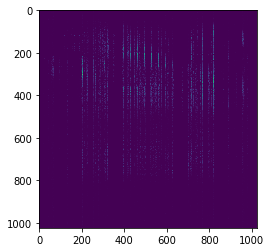

In [54]:
plt.imshow(intImage)
plt.show()

In [50]:
@jit(nopython=True)
def arrDefine(inputnumber):
    test = np.zeros((12, 12), dtype = np.int16)
    
    
    test[10][10] = test[10][10] + 1
    
    return test

In [51]:
arrDefine(1)

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=int16)